### Resolução lista I - Lucas Dias Rodrigues

In [78]:
import numpy as np
import numpy.random as rng
import matplotlib.pyplot as plt
import time

##### $\pi$ por Monte Carlo

In [79]:
#1 
N = 10000

def pi_monte_carlo(N): #calcula pelo método de Monte Carlo o valor aproximado de pi

    dentro = 0
    for x in range(N):

        x = rng.rand()
        y = rng.rand()

        if x**2 + y**2 <= 1:
            dentro += 1 #conta o número de pontos dentro do círculo

    return 4*dentro/N

print(pi_monte_carlo(N))

3.1428


In [80]:
N = 1000 #numero de iterações
#2
def pi_monte_carlo2(N, retorna_pontos = True):

    dentro, fora = [], []

    for x in range(N):
    
        x = rng.rand()
        y = rng.rand()
    
        if x**2 + y**2 <= 1: dentro.append((x,y)) #adiciona nos arrays os pares ordenados dentro e fora para os respectivos arryas
        else: fora.append((x,y))

        estimativa_pi = 4*len(dentro)/N

    if retorna_pontos: return estimativa_pi, dentro, fora #dá a opção de armazenar ou não os arrays
    else: return estimativa_pi

y = lambda x: np.sqrt(1-x**2) #função setor circular

resultado = pi_monte_carlo2(N)
x_axis = np.linspace(0,1,200) #define o eixo x do plot

x_dentro, y_dentro = np.array(resultado[1])[:,0], np.array(resultado[1])[:,1] #desempacota os arrays para x e y 'dentro'

x_fora, y_fora = np.array(resultado[2])[:,0], np.array(resultado[2])[:,1] #desempacota 'fora'



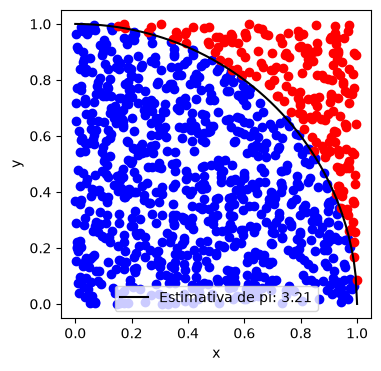

In [ ]:
#gráfico
plt.figure(figsize=(4,4))

plt.plot(x_axis, y(x_axis), color="black", label=f"Estimativa de pi: {resultado[0]:.2f}") #plot da linha que delimita o setor circular
plt.scatter(x_dentro, y_dentro, color="blue")
plt.scatter(x_fora, y_fora, color="red")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

In [82]:
#4 versão rápida do código
def pi_monte_carlo_rapido(N):

    x3, y3 = rng.rand(N), rng.rand(N) #vetoriza a geração dos números aleatórios
    s = x3**2 + y3**2
    dentro = np.sum(s < 1) #soma sobre o Booleano s < 1

    return 4*dentro/N



In [ ]:
#3
eixo_erro_rapido = []
eixo_erro_lento = []
eixo_tempo_rapido = []
eixo_tempo_lento = []
n_tentativas = 10

def erro_rapido(N): 
    return abs(pi_monte_carlo_rapido(N) - np.pi)/np.pi #função de cálculo do erro relativo (rápido)

def erro_lento(N):
    return abs((pi_monte_carlo(N) - np.pi)/ np.pi)

N_pontos = np.array([10, 100, 1000, 10**4, 10**5, 10**6])

for item in N_pontos: #loop que varia o número de pontos

    erro_medio_rapido,tempo_medio_rapido = 0, 0
    erro_medio_lento, tempo_medio_lento = 0, 0

    for i in range(n_tentativas): #loop para cálculo da média de 10 execuções com número fixo de pontos tanto para o código rápido quanto para o lento

        start_rapido = time.time()
        erro_medio_rapido += erro_rapido(item)/n_tentativas
        end_rapido = time.time()

        start_lento = time.time()
        erro_medio_lento += erro_lento(item)/n_tentativas
        end_lento = time.time()

        tempo_exec_rapido = (end_rapido - start_rapido)/n_tentativas 
        tempo_exec_lento = (end_lento - start_lento)/n_tentativas
        tempo_medio_rapido += tempo_exec_rapido
        tempo_medio_lento += tempo_exec_lento

    eixo_erro_rapido.append(erro_medio_rapido)
    eixo_erro_lento.append(erro_medio_lento)
    eixo_tempo_rapido.append(tempo_medio_rapido)
    eixo_tempo_lento.append(tempo_medio_lento)

regressao_linear = np.polyfit(np.log(N_pontos), np.log(eixo_erro_rapido), 1) #faz o fit linear do loglog dos dados

a, b = regressao_linear #extrai os coeficientes angular e linear

def reta(x):
    return a*x + b #define a reta do ajuste

N_continuo = np.linspace(10, 10**6, 100)


Coeficiente angular: -0.50 
Coeficiente linear: -0.84


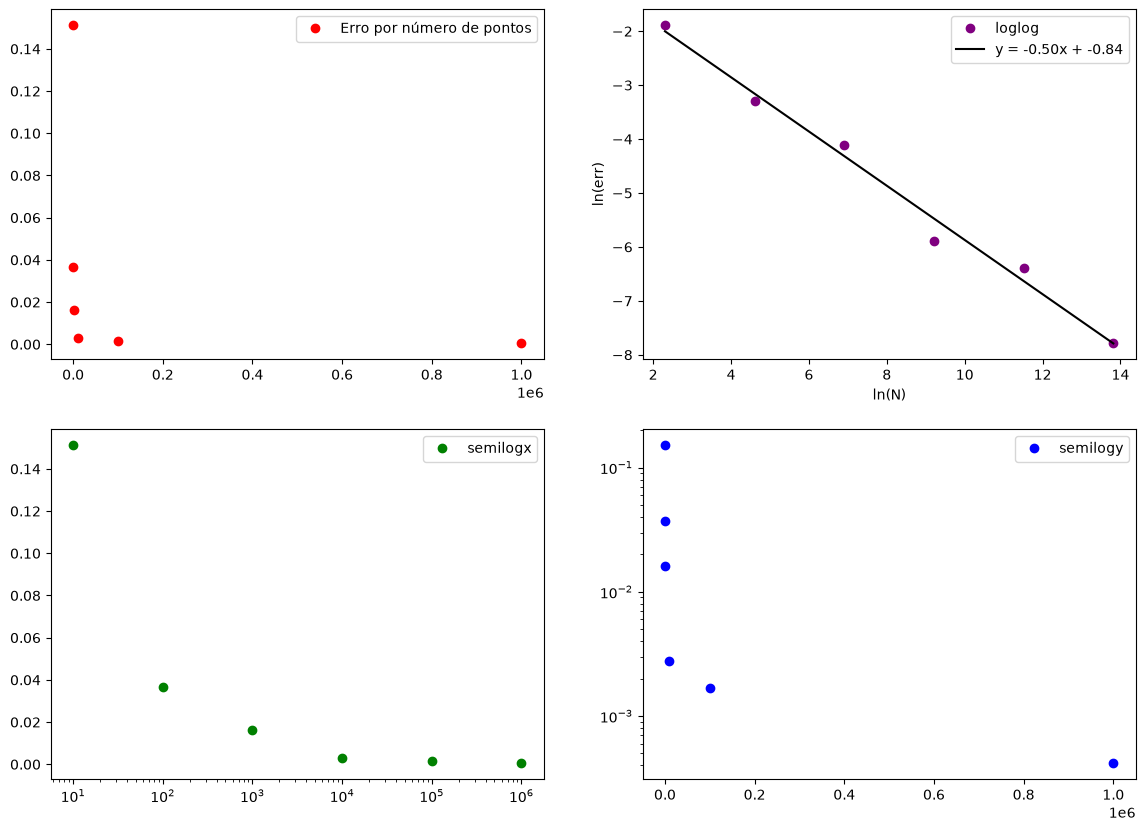

In [84]:
#grafico
plt.figure(figsize=(14,10))

plt.subplot(2,2,1) #painel do erro em função da quantidade de pontos
plt.plot(N_pontos, eixo_erro_rapido, 'o', color="red",label="Erro por número de pontos")
plt.legend()

plt.subplot(2,2,2)
plt.plot(np.log(N_pontos), np.log(eixo_erro_rapido), 'o', color="purple", label="loglog") #em escala loglog
plt.plot(np.log(N_continuo), reta(np.log(N_continuo)), color="black", label=f"y = {a:.2f}x + {b:.2f}")
plt.xlabel("ln(N)")
plt.ylabel("ln(err)")
plt.legend()

plt.subplot(2,2,3) #em escala semilogx
plt.semilogx(N_pontos, eixo_erro_rapido, 'o', color="green",label="semilogx")
plt.legend()

plt.subplot(2,2,4) #em escala semilogy
plt.semilogy(N_pontos, eixo_erro_rapido, 'o', color="blue", label="semilogy")
plt.legend()

print(f"Coeficiente angular: {a:.2f}", f"\nCoeficiente linear: {b:.2f}")
plt.show()

A partir desses gráficos a lei de potência fica evidente: $\ln(Erro) \approx -0.5\ln(N) - 0.84$ ou seja,
$Erro \approx 0.4 \frac{1}{\sqrt{N}} N$

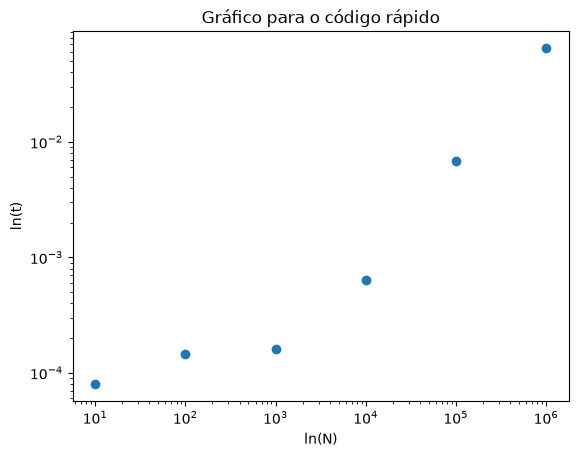

In [ ]:
plt.loglog(N_pontos, eixo_tempo_rapido, 'o') #plot para o tempo médio de execução em função do número de pontos (rápido)
plt.ylabel("ln(t)")
plt.xlabel("ln(N)")
plt.title("Gráfico para o código rápido")
plt.show()


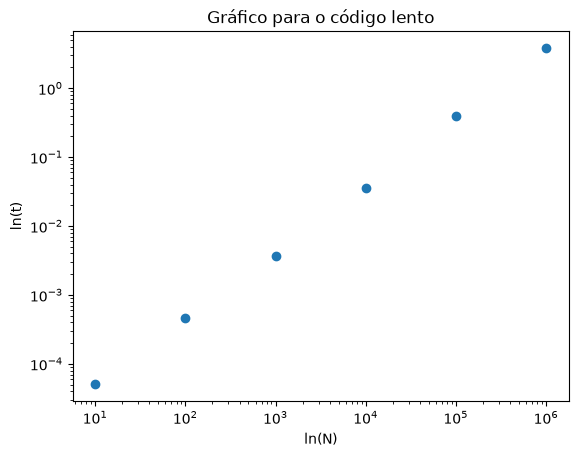

In [86]:
plt.loglog(N_pontos, eixo_tempo_lento, 'o') #plot para o tempo médio de execução em função do número de pontos (lento)
plt.ylabel("ln(t)")
plt.xlabel("ln(N)")
plt.title("Gráfico para o código lento")
plt.show()
